# Model Selection and Hyperparameter Tuning on a Large Synthetic Classification Dataset

In this notebook we follow the **shallow-model training framework** from Lecture 12:

1. Generate a large synthetic binary-classification dataset (100 k rows).
2. Perform exploratory analysis to justify the train/validation/test split and stratification choices.
3. Define a primary performance metric (ROC-AUC) and secondary diagnostic metrics.
4. Establish a zero-rule baseline** and evaluate it.
5. Train three learning algorithms with **default hyperparameters** and compare them on the validation set:
   - Logistic Regression
   - Random Forest
   - Gradient Boosting
6. Perform **hyperparameter tuning** (training set + cross-validation only):
   - Grid Search: Logistic Regression
   - Randomized Search: Random Forest
   - Bayesian Optimization: Gradient Boosting
7. Perform **threshold tuning** (validation set, no retraining).
8. Select the best model based on the primary metric P (ROC-AUC).
9. Retrain the selected model on train + validation.
10. **Evaluate once** on the sealed test set.
11. Compare final performance with baselines and pre-merge validation.
12. Conclusions and proposed exercises.

In [14]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Models and baseline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay,
)

# Bayesian Optimization
from skopt import BayesSearchCV

sns.set_theme(style="whitegrid")

# Suppress benign sklearn internal warnings
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

## Helper functions

These are functions we code to beautify the output and avoid some code repetitions. In production environments, we would keep them into a support module we would load in specific contexts (i.e., producing a report or coding a ML pipeline outside of a notebook).

In [15]:
def compute_metrics(y_true, y_pred, y_score=None):
    """Return a dict of standard classification metrics.
    y_score: predicted probabilities for the positive class (needed for ROC-AUC).
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    return metrics


def display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test):
    df = pd.DataFrame({
        "Set": ["Train", "Validation", "Test"],
        "X shape": [X_train.shape, X_val.shape, X_test.shape],
        "y shape": [y_train.shape, y_val.shape, y_test.shape],
    })
    display(df.style.hide(axis="index"))


def display_metrics(name, metrics, decimals=4):
    print(f"\n{name}")
    df = pd.DataFrame([metrics]).round(decimals)
    display(df.style.hide(axis="index"))


def display_model_results(name, best_params, metrics, decimals=4):
    print(f"\n{name} — Best Parameters")
    display(pd.DataFrame([best_params]).style.hide(axis="index"))
    print(f"{name} — Validation Metrics")
    display(pd.DataFrame([metrics]).round(decimals).style.hide(axis="index"))


# Accumulator for the summary table
results_table = []

def add_result(name, split, metrics, best_params=None, notes=None):
    row = {
        "Model": name,
        "Split": split,
        "Accuracy": metrics.get("accuracy"),
        "Precision": metrics.get("precision"),
        "Recall": metrics.get("recall"),
        "F1": metrics.get("f1"),
        "ROC-AUC": metrics.get("roc_auc"),
        "Notes": notes,
    }
    if best_params:
        row["Best Params"] = ", ".join(f"{k}={v}" for k, v in best_params.items())
    else:
        row["Best Params"] = None
    results_table.append(row)


def show_results(sort_by=("Split", "ROC-AUC"), ascending=(True, False), decimals=4):
    df = pd.DataFrame(results_table)
    if df.empty:
        print("results_table is empty.")
        return df
    df_sorted = df.sort_values(list(sort_by), ascending=list(ascending))
    display(df_sorted.round(decimals).style.hide(axis="index"))
    return df_sorted

## Step 1: Data Generation

We generate a large synthetic binary-classification dataset with 100 000 samples and 20 features (6 informative, 4 redundant, 10 noise). We introduce 3 % label noise (`flip_y=0.03`) to make the problem nontrivial.

We do **not** split the data yet. We first inspect the target distribution to make an informed decision about the splitting strategy.

In [16]:
X, y = make_classification(
    n_samples=100_000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_clusters_per_class=2,
    class_sep=1.0,
    flip_y=0.03,
    random_state=42,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: {np.bincount(y)}")

X shape: (100000, 20)
y shape: (100000,)
Class distribution: [49962 50038]


## Step 2: Exploratory Analysis

Before splitting, we inspect the data to answer two questions:

1. **What split ratio?** With 100 k samples, a 60/20/20 split gives 60 k for training, 20 k for validation, and 20 k for test. Each partition is large enough that metric estimates have low sampling variance, and the training set is large enough for models with moderate capacity.

1. **Do we need stratification?** If the two classes are balanced (~50/50), random splitting will preserve the balance by the law of large numbers. If they are imbalanced, we must use `stratify=y` in both splits to avoid skewing the class distribution across partitions.

Class counts: [49962 50038]
Class fractions: [0.4996 0.5004]


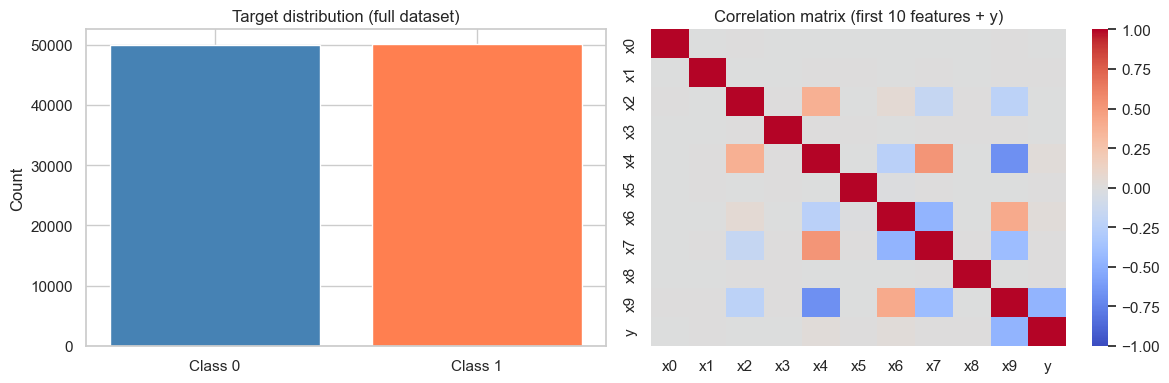


Imbalance ratio (minority/majority): 0.9985


In [17]:
# Class balance
class_counts = np.bincount(y)
class_fractions = class_counts / len(y)

print("Class counts:", class_counts)
print("Class fractions:", class_fractions.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of class distribution
axes[0].bar(["Class 0", "Class 1"], class_counts, color=["steelblue", "coral"])
axes[0].set_title("Target distribution (full dataset)")
axes[0].set_ylabel("Count")

# Feature-correlation heatmap (subset of features for readability)
feature_df = pd.DataFrame(X[:, :10], columns=[f"x{i}" for i in range(10)])
feature_df["y"] = y
sns.heatmap(feature_df.corr(), ax=axes[1], cmap="coolwarm", center=0, vmin=-1, vmax=1)
axes[1].set_title("Correlation matrix (first 10 features + y)")

plt.tight_layout()
plt.show()

# Quantify imbalance
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"\nImbalance ratio (minority/majority): {imbalance_ratio:.4f}")


With imbalance ratio > 0.9, classes are nearly balanced. Stratification is good practice but not critical at 100 k. For imbalance ratio < 0.9, i.e., even when some imbalance is detected, stratification is necessary.

### 2.1 Train/Validation/Test Split (60/20/20)

We perform two sequential splits, both stratified on `y`:

1. 80% -> `X_train_full`/20% -> `X_test`
2. 75% of `X_train_full` (= 60% overall) -> `X_train`/25% (= 20% overall) -> `X_val`

In [18]:
# First split: separate out the test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)

# Second split: training (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full,
)

display_dataset_split(X_train, y_train, X_val, y_val, X_test, y_test)

# Verify stratification preserved class balance
for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    frac = labels.mean()
    print(f"  {name:6s}  class-1 fraction = {frac:.4f}")

Set,X shape,y shape
Train,"(60000, 20)","(60000,)"
Validation,"(20000, 20)","(20000,)"
Test,"(20000, 20)","(20000,)"


  Train   class-1 fraction = 0.5004
  Val     class-1 fraction = 0.5003
  Test    class-1 fraction = 0.5004


## Step 3: Defining Performance Metrics

### Primary metric: ROC-AUC

We choose ROC-AUC as the primary performance metric P because:

- It is threshold-independent: it evaluates the model's ability to rank positive instances above negative instances, irrespective of any decision boundary.
- It is well suited for **model selection and hyperparameter tuning**, where we want to compare model capacity without conflating it with a threshold choice.
- For balanced classes (as in our dataset), ROC-AUC and other metrics tend to agree on model ordering, but ROC-AUC remains informative even if the class balance shifts.

### Secondary diagnostic metrics

We also report the following at a fixed threshold (default 0.5 unless otherwise stated) to provide complementary insight:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall fraction of correct predictions. |
| **Precision** | Of all predicted positives, how many are truly positive. |
| **Recall (Sensitivity/TPR)** | Of all true positives, how many are correctly identified. |
| **F1 Score** | Harmonic mean of precision and recall — useful when both matter. |

These threshold-dependent metrics become especially important in Step 9 (threshold tuning), where we explicitly trade off precision and recall at a chosen operating point.

> Key distinction:
> - Steps 4–8 use ROC-AUC (threshold-independent) for model capacity comparison.
> - Step 9 uses the ROC curve to select a decision threshold (precision–recall tradeoff).
> - Step 10–12 apply the selected threshold on the sealed test set.

## Step 4: Zero-Rule Baseline

The zero-rule baseline always predicts the most frequent class. It learns nothing from `X`.

Any useful model must exceed this baseline. If it does not, the pipeline is likely broken.

In [19]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

dummy_val_pred = dummy.predict(X_val)
dummy_val_score = dummy.predict_proba(X_val)[:, 1]

dummy_val_metrics = compute_metrics(y_val, dummy_val_pred, dummy_val_score)
add_result("Zero-rule (Dummy)", "val", dummy_val_metrics, notes="most_frequent baseline")
display_metrics("Zero-rule baseline — Validation", dummy_val_metrics)


Zero-rule baseline — Validation


accuracy,precision,recall,f1,roc_auc
0.500400,0.500400,1.000000,0.667000,0.500000


### Interpretation

The zero-rule model predicts class 1 for every sample (the majority class, 50 038 vs 49 962):

- **Accuracy = 0.5004**: the dataset is almost perfectly balanced, so always predicting one class
  is right roughly half the time.
- **Precision = 0.5004**: half of its "positive" predictions are correct (it labels everything positive).
- **Recall = 1.00**: it catches every true positive because it predicts every sample as positive.
- **F1 = 0.667**: the harmonic mean of precision (~0.50) and recall (1.0).
- **ROC-AUC = 0.50**: a constant score cannot rank positives above negatives.

This is the performance floor. Notice that recall looks "good" (1.0) while the model is trivial. This is why metrics must always be interpreted together, never in isolation.

> What would change with an imbalanced dataset? If, say, 95 % of samples were class 0, the zero-rule model would predict class 0 for every sample, achieving accuracy = 0.95 but recall = 0 for the minority class. Accuracy alone would look impressive while the model is useless for minority detection. This is why ROC-AUC (or PR-AUC) is preferred as the primary metric when classes are imbalanced.

## Step 5: Logistic Regression

We train a Logistic Regression with default/minimal hyperparameters. This serves as the first real baseline: it uses feature information but has not been tuned. We evaluate on the validation set and compare against the zero-rule baseline.

In [20]:
%%time

lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_default.fit(X_train, y_train)

lr_default_val_pred = lr_default.predict(X_val)
lr_default_val_score = lr_default.predict_proba(X_val)[:, 1]

lr_default_val_metrics = compute_metrics(y_val, lr_default_val_pred, lr_default_val_score)
add_result("LogReg (default)", "val", lr_default_val_metrics, notes="default hyperparameters")
display_metrics("Logistic Regression (default) — Validation", lr_default_val_metrics)


Logistic Regression (default) — Validation


accuracy,precision,recall,f1,roc_auc
0.847400,0.873900,0.812200,0.841900,0.907900


CPU times: total: 46.9 ms
Wall time: 42.1 ms


### Comparison: Zero-rule vs Logistic Regression (default)

Logistic Regression substantially improves over the zero-rule baseline across all metrics, confirming that it is learning from the features:

| Metric | Zero-rule | LR (default) |
|---|---|---|
| ROC-AUC | 0.50 | **0.908** |
| Accuracy | 0.50 | 0.847 |
| Precision | 0.50 | 0.874 |
| Recall | 1.00 | 0.812 |
| F1 | 0.67 | 0.842 |

ROC-AUC ~0.91 indicates good ranking quality: positives generally receive higher predicted probabilities than negatives. Notice that precision > recall (0.874 vs 0.812), meaning at the default threshold of 0.5 the model is slightly conservative, i.e., it misses some positives (more false negatives than false positives). This is a common pattern for linear models on data with nonlinear structure: the decision boundary cannot wrap tightly around both classes.

> If the dataset were imbalanced, we would expect the default LR to favor the majority class even more, further widening the precision–recall gap for the minority class.

## Step 6: Random Forest

We train a Random Forest with default hyperparameters and compare against Logistic Regression. Random Forest is a bagging ensemble of decision trees. Its higher capacity should allow it to capture nonlinear interactions that a linear model cannot represent.

In [21]:
%%time

rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

rf_default_val_pred = rf_default.predict(X_val)
rf_default_val_score = rf_default.predict_proba(X_val)[:, 1]

rf_default_val_metrics = compute_metrics(y_val, rf_default_val_pred, rf_default_val_score)
add_result("Random Forest (default)", "val", rf_default_val_metrics, notes="default hyperparameters")
display_metrics("Random Forest (default) — Validation", rf_default_val_metrics)


Random Forest (default) — Validation


accuracy,precision,recall,f1,roc_auc
0.940900,0.958300,0.922000,0.939800,0.975600


CPU times: total: 25.9 s
Wall time: 2.9 s


## Step 7: Gradient Boosting

We train a Gradient Boosting Classifier with default hyperparameters. Gradient Boosting is a sequential ensemble that builds trees to correct the errors of the previous ensemble. It often achieves higher accuracy than Random Forest at the cost of longer training time.

In [22]:
%%time

gbc_default = GradientBoostingClassifier(random_state=42)
gbc_default.fit(X_train, y_train)

gbc_default_val_pred = gbc_default.predict(X_val)
gbc_default_val_score = gbc_default.predict_proba(X_val)[:, 1]

gbc_default_val_metrics = compute_metrics(y_val, gbc_default_val_pred, gbc_default_val_score)
add_result("Gradient Boosting (default)", "val", gbc_default_val_metrics, notes="default hyperparameters")
display_metrics("Gradient Boosting (default) — Validation", gbc_default_val_metrics)


Gradient Boosting (default) — Validation


accuracy,precision,recall,f1,roc_auc
0.913800,0.942400,0.881700,0.911000,0.963900


CPU times: total: 33 s
Wall time: 33.2 s


### Comparison: Default Models on Validation

We compare all default models using the primary metric (ROC-AUC) and secondary metrics.

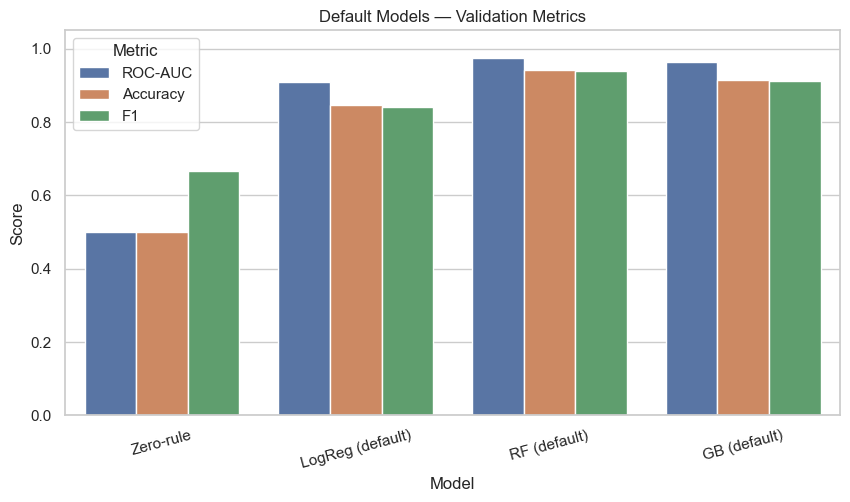

,Model,ROC-AUC,Accuracy,F1
0,Zero-rule,0.5000,0.5004,0.6670
1,LogReg (default),0.9079,0.8474,0.8419
2,RF (default),0.9756,0.9409,0.9398
3,GB (default),0.9639,0.9138,0.9110


In [23]:
default_comparison = pd.DataFrame({
    "Model": ["Zero-rule", "LogReg (default)", "RF (default)", "GB (default)"],
    "ROC-AUC": [
        dummy_val_metrics.get("roc_auc", np.nan),
        lr_default_val_metrics["roc_auc"],
        rf_default_val_metrics["roc_auc"],
        gbc_default_val_metrics["roc_auc"],
    ],
    "Accuracy": [
        dummy_val_metrics["accuracy"],
        lr_default_val_metrics["accuracy"],
        rf_default_val_metrics["accuracy"],
        gbc_default_val_metrics["accuracy"],
    ],
    "F1": [
        dummy_val_metrics["f1"],
        lr_default_val_metrics["f1"],
        rf_default_val_metrics["f1"],
        gbc_default_val_metrics["f1"],
    ],
})

melted = default_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Score", hue="Metric", data=melted)
plt.title("Default Models — Validation Metrics")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.show()

display(default_comparison.round(4))

### Interpretation: Default Models

All three learners substantially outperform the zero-rule baseline, confirming useful signal in the features. The tree-based ensembles outperform Logistic Regression, indicating nonlinear structure that a linear model cannot fully capture.

Notably, Random Forest outperforms Gradient Boosting at default settings (ROC-AUC 0.976 vs 0.964). This often happens because sklearn's RF defaults (100 deep, unpruned trees) are quite aggressive, while GB's defaults (100 trees, `max_depth=3`, `learning_rate=0.1`) are deliberately conservative to prevent overfitting. GB typically needs tuning (more trees, deeper trees, or a smaller learning rate) to realize its full potential.

This comparison establishes a **before-tuning reference** for each algorithm. We will check in Step 8 whether tuning reverses this ranking; in particular, whether GB can overtake RF once its hyperparameters are optimized.

> With imbalanced data, default accuracy would be misleading (a classifier predicting the majority class would already score high). Tree ensembles would still rank well on ROC-AUC, but F1 for the minority class would become a critical secondary metric. In practice, you would also inspect Precision-Recall AUC (PR-AUC), which is more sensitive to minority-class performance than ROC-AUC.

## Step 8: Hyperparameter Tuning

We tune each algorithm's hyperparameters using only the training set (with internal cross-validation). The validation set is held out for model selection after tuning. Note that no test data is involved in this step.

We use the primary metric ROC-AUC as the scoring function for all searches. We apply a different search strategy per algorithm to illustrate the range of available methods:

- **Grid Search**: Logistic Regression (small parameter space, exhaustive search is feasible).
- **Randomized Search**: Random Forest (moderate space, random sampling is efficient).
- **Bayesian Optimization**: Gradient Boosting (continuous spaces, Bayesian surrogate is sample-efficient).

> Note on computational cost: A full 3*3 comparison matrix (3 algorithms * 3 search methods) is infeasible on a standard laptop. We therefore assign one search method per algorithm, chosen to match the algorithm's hyperparameter-space characteristics.

### 8.1 Logistic Regression — Grid Search

We search over:

- **C** (inverse regularization strength): logarithmically spaced from $10^{-3}$ to $10^{3}$. Smaller C implies stronger regularization (higher bias, lower variance).
- **l1_ratio** (penalty type): controls how the regularization shrinks coefficients.
  - `l1_ratio = 0` is a pure L2 (ridge): shrinks coefficients smoothly, never to zero.
  - `l1_ratio = 1` is a pure L1 (lasso): promotes sparsity by pushing some coefficients to exactly zero.

We use `solver='saga'`, which supports the full range of `l1_ratio` values. In scikit-learn ≥ 1.8, the `penalty=` parameter is deprecated in favor of controlling regularization via `C` and `l1_ratio`
directly.

We use 5-fold cross-validation, scoring on ROC-AUC, and then evaluate the best configuration on the validation set.

In [24]:
%%time

lr_model = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=42,
)

lr_param_grid = {
    "C": np.logspace(-3, 3, 7),
    "l1_ratio": [0.0, 1.0],   # 0 = pure L2, 1 = pure L1
}

lr_grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

lr_grid_search.fit(X_train, y_train)

lr_val_pred = lr_grid_search.predict(X_val)
lr_val_score = lr_grid_search.predict_proba(X_val)[:, 1]

Fitting 5 folds for each of 14 candidates, totalling 70 fits
CPU times: total: 438 ms
Wall time: 21.9 s


In [25]:
lr_val_metrics = compute_metrics(y_val, lr_val_pred, lr_val_score)
add_result(
    "LogReg tuned (GridSearch)", "val", lr_val_metrics,
    best_params=lr_grid_search.best_params_,
    notes="CV=5, scoring=roc_auc",
)
display_model_results("Logistic Regression (Grid Search)", lr_grid_search.best_params_, lr_val_metrics)


Logistic Regression (Grid Search) — Best Parameters


C,l1_ratio
0.010000,1.000000


Logistic Regression (Grid Search) — Validation Metrics


accuracy,precision,recall,f1,roc_auc
0.847700,0.874300,0.812400,0.842200,0.907900


#### Visualization: Grid Search Results for Logistic Regression

This plot shows how the mean CV ROC-AUC changes with regularization strength **C**, comparing
L1 and L2 penalties.

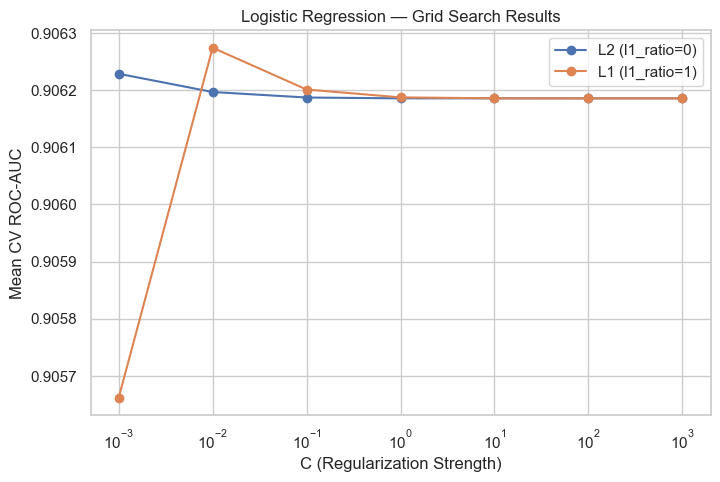

In [26]:
lr_results = pd.DataFrame(lr_grid_search.cv_results_)

plt.figure(figsize=(8, 5))
for ratio in lr_param_grid["l1_ratio"]:
    subset = lr_results[lr_results["param_l1_ratio"] == ratio]
    label = "L2 (l1_ratio=0)" if ratio == 0 else "L1 (l1_ratio=1)"
    plt.semilogx(subset["param_C"], subset["mean_test_score"], marker="o", label=label)

plt.xlabel("C (Regularization Strength)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("Logistic Regression — Grid Search Results")
plt.legend()
plt.show()

#### Interpretation

The grid search selected C = 0.01, l1_ratio = 1.0 (pure L1 / Lasso). Yet, the tuned validation ROC-AUC is 0.9079, identical to the default LR (which uses L2 with C = 1.0). This tells us two things:

1. The ROC-AUC plateau is flat. Across most of the C range, performance barely changes. Logistic Regression has already extracted all the *linear* signal it can; regularization type and strength make little difference.
2. Tuning cannot compensate for a capacity ceiling. The LR decision boundary is a hyperplane. If the true boundary is nonlinear, no amount of regularization tuning will help.

The plot shows L1 and L2 curves converging once C is large enough (≳ 10⁻²). At very small C (strong regularization) L1 may underperform slightly because it zeroes out features aggressively, but in this dataset the effect is minor.

### 8.2 Random Forest — Randomized Search

We search over:

- `n_estimators`: 50, 100, 200 trees.
- `max_depth`: None (unlimited), 10, 20, 30.
- `min_samples_split`: 2, 5, 10 (minimum samples to split a node).
- `min_samples_leaf`: 1, 2, 4 (minimum samples per leaf).

Total space: 3 * 4 * 3 * 3 = 108 combinations. We sample 50 random configurations (each
evaluated with 5-fold CV) rather than exhaustively searching all 108.

In [27]:
%%time

# n_jobs is set on the search, not the estimator, to avoid nested-parallelism.
rf_model = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

rf_random_search.fit(X_train, y_train)

rf_val_pred = rf_random_search.predict(X_val)
rf_val_score = rf_random_search.predict_proba(X_val)[:, 1]

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: total: 344 ms
Wall time: 2min 32s


KeyboardInterrupt: 

In [ ]:
rf_val_metrics = compute_metrics(y_val, rf_val_pred, rf_val_score)
add_result(
    "Random Forest (RandomizedSearch)", "val", rf_val_metrics,
    best_params=rf_random_search.best_params_,
    notes="CV=5, scoring=roc_auc",
)
display_model_results("Random Forest (Randomized Search)", rf_random_search.best_params_, rf_val_metrics)

### 8.3 Gradient Boosting — Bayesian Optimization

We use `BayesSearchCV` to efficiently search a continuous/mixed hyperparameter space:

- `n_estimators`: 50–300 (integer range).
- `learning_rate`: 0.01–1.0 (log-uniform — appropriate because the effect of learning rate is multiplicative).
- `max_depth`: 3–10 (integer range).
- `subsample`: 0.5–1.0 (uniform — fraction of samples used per boosting stage).

Bayesian optimization builds a probabilistic surrogate model of the objective function
(ROC-AUC) and uses it to decide where to evaluate next. This is more sample-efficient
than random search for smooth, continuous spaces.

In [ ]:
%%time

gbc_model = GradientBoostingClassifier(random_state=42)

gbc_param_space = {
    "n_estimators": (50, 300),
    "learning_rate": (0.01, 1.0, "log-uniform"),
    "max_depth": (3, 10),
    "subsample": (0.5, 1.0, "uniform"),
}

gbc_bayes_search = BayesSearchCV(
    estimator=gbc_model,
    search_spaces=gbc_param_space,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

gbc_bayes_search.fit(X_train, y_train)

gbc_val_pred = gbc_bayes_search.predict(X_val)
gbc_val_score = gbc_bayes_search.predict_proba(X_val)[:, 1]

In [ ]:
gbc_val_metrics = compute_metrics(y_val, gbc_val_pred, gbc_val_score)
add_result(
    "Gradient Boosting (BayesSearch)", "val", gbc_val_metrics,
    best_params=gbc_bayes_search.best_params_,
    notes="CV=5, scoring=roc_auc",
)
display_model_results("Gradient Boosting (Bayesian Optimization)", gbc_bayes_search.best_params_, gbc_val_metrics)

### 8.4 Comparison: Tuned Models on Validation

We compare **all** models (default + tuned) on the validation set using the primary metric (ROC-AUC).

In [ ]:
tuned_comparison = pd.DataFrame({
    "Model": [
        "LogReg (default)", "LogReg (tuned)",
        "RF (default)", "RF (tuned)",
        "GB (default)", "GB (tuned)",
    ],
    "ROC-AUC": [
        lr_default_val_metrics["roc_auc"], lr_val_metrics["roc_auc"],
        rf_default_val_metrics["roc_auc"], rf_val_metrics["roc_auc"],
        gbc_default_val_metrics["roc_auc"], gbc_val_metrics["roc_auc"],
    ],
    "Accuracy": [
        lr_default_val_metrics["accuracy"], lr_val_metrics["accuracy"],
        rf_default_val_metrics["accuracy"], rf_val_metrics["accuracy"],
        gbc_default_val_metrics["accuracy"], gbc_val_metrics["accuracy"],
    ],
    "F1": [
        lr_default_val_metrics["f1"], lr_val_metrics["f1"],
        rf_default_val_metrics["f1"], rf_val_metrics["f1"],
        gbc_default_val_metrics["f1"], gbc_val_metrics["f1"],
    ],
})

melted = tuned_comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="Score", hue="Metric", data=melted)
plt.title("Default vs Tuned Models — Validation Metrics")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(tuned_comparison.round(4))

#### Interpretation: Tuned Model Comparison

| Model | Default ROC-AUC | Tuned ROC-AUC | Δ |
|---|---|---|---|
| LogReg | 0.9079 | 0.9079 | 0.0000 |
| RF | 0.9757 | 0.9761 | +0.0004 |
| GB | 0.9639 | 0.9788 | +0.0149 |

Three key findings:

1. LogReg: no improvement. The linear model is capacity-limited; tuning regularization cannot overcome a fundamentally linear decision boundary on nonlinear data.
2. RF: marginal improvement. sklearn's RF defaults are already strong (100 deep, unpruned trees). There is little headroom to improve.
3. GB: largest gain, now the best model. Gradient Boosting jumped from 0.964 to 0.979, overtaking RF. The Bayesian search found `learning_rate ~0.047`, `n_estimators = 300`, `max_depth = 10`, `subsample ~0.77` — a classic "many small steps with deep trees" regime that balances expressiveness with regularization through subsampling.

Why does GB benefit most? Its conservative defaults (`max_depth=3`, `n_estimators=100`, `learning_rate=0.1`) deliberately under-fit. Tuning unlocks capacity that was deliberately held back, whereas RF's defaults already allow deep, complex trees.

> With imbalanced data, model rankings can shift. RF's bagging gives it natural robustness to imbalance (each tree sees a bootstrapped sample), while GB's sequential correction can fixate on misclassified majority-class samples unless `class_weight` or sampling strategies are used. Always re-evaluate rankings under the target class distribution.

> Important: All comparisons so far use the validation set. The test set remains sealed.

## Step 9: Threshold Tuning

Up to this point, all threshold-dependent metrics used the default threshold of 0.5.

The decision threshold is a prediction-stage hyperparameter: changing it does not retrain
the model. It controls how aggressively the model predicts the positive class, trading off
precision (fewer false positives) against recall (fewer false negatives).

We select the best-performing model on the primary metric (ROC-AUC) and use its ROC curve on the
validation set to choose an operating threshold.

Threshold selection criterion: We maximize $\text{TPR} - \text{FPR}$ (also called Youden's J statistic or Youden's index), which selects the point on the ROC curve farthest from the diagonal (random chance).

In [ ]:
# ── Select the best model by validation ROC-AUC ──
candidate_models = {
    "LogReg (tuned)": (lr_grid_search.best_estimator_, lr_val_metrics["roc_auc"]),
    "RF (tuned)": (rf_random_search.best_estimator_, rf_val_metrics["roc_auc"]),
    "GB (tuned)": (gbc_bayes_search.best_estimator_, gbc_val_metrics["roc_auc"]),
}

best_model_name = max(candidate_models, key=lambda k: candidate_models[k][1])
best_estimator = candidate_models[best_model_name][0]
best_val_roc_auc = candidate_models[best_model_name][1]

print(f"Best model (validation ROC-AUC = {best_val_roc_auc:.4f}): {best_model_name}")

# ── Compute ROC curve on validation ──
val_proba = best_estimator.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, val_proba)
roc_auc = roc_auc_score(y_val, val_proba)

# ── Select threshold (maximize Youden's J = TPR - FPR) ──
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
selected_threshold = float(thresholds[best_idx])

print(f"Selected threshold (Youden's J): {selected_threshold:.4f}")
print(f"  TPR = {tpr[best_idx]:.4f},  FPR = {fpr[best_idx]:.4f}")

In [ ]:
# ── Compare default threshold vs selected threshold ──
def metrics_at_threshold(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    return {
        "threshold": float(thr),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),  # threshold-independent, same either way
    }

metrics_default = metrics_at_threshold(y_val, val_proba, 0.5)
metrics_selected = metrics_at_threshold(y_val, val_proba, selected_threshold)

display(
    pd.DataFrame([
        {"method": "default (threshold=0.5)", **metrics_default},
        {"method": f"selected (threshold={selected_threshold:.4f})", **metrics_selected},
    ]).round(4).style.hide(axis="index")
)

# ── Plot ROC curve ──
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
plt.scatter([fpr[best_idx]], [tpr[best_idx]], s=100, zorder=5,
            label=f"Selected threshold = {selected_threshold:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="grey")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title(f"ROC Curve (validation) — {best_model_name}")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Interpretation: Threshold Tuning

The selected threshold is 0.4513, slightly below the default 0.5. This nudges the model toward more positive predictions, trading a small amount of precision for higher recall:

| | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Default | 0.5000 | 0.9464 | 0.9584 | 0.9333 | 0.9457 | 0.9788 |
| Selected | 0.4513 | 0.9466 | 0.9547 | 0.9377 | 0.9462 | 0.9788 |

The shift is small because the dataset is balanced and the model is well-calibrated near 0.5. ROC-AUC is identical in both rows, but this is expected because it is threshold-independent by definition.

> With imbalanced data, threshold tuning becomes much more impactful. The default 0.5 typically under-predicts the minority class (low recall). Youden's J or an F1-maximizing threshold would push the threshold well below 0.5, sometimes to 0.1–0.3, dramatically improving minority-class recall at the cost of more false positives. This is often an acceptable tradeoff in applications like fraud detection or medical screening.

> Key takeaway: Threshold tuning is a precision–recall tradeoff decision. It does not change the model and does not affect ROC-AUC. We fix the selected threshold and carry it forward to the final test evaluation.

## Step 10: Model Selection Summary

We select the model with the highest validation ROC-AUC. This is the model whose capacity best fits the data, as measured by the threshold-independent primary metric.

In [ ]:
# Store pre-merge validation metrics for later comparison
pre_merge_val_metrics = compute_metrics(y_val, (val_proba >= selected_threshold).astype(int), val_proba)
pre_merge_val_metrics["threshold"] = selected_threshold

print(f"Selected model: {best_model_name}")
print(f"Pre-merge validation metrics (with selected threshold):")
display(pd.DataFrame([pre_merge_val_metrics]).round(4).style.hide(axis="index"))

## Step 11: Retrain on Train + Validation

We retrain the selected model (with its tuned hyperparameters) on the combined training + validation data. The model keeps its hyperparameters from tuning; we only update the fitted weights with more data.

Why retrain? After model selection, the validation set has served its purpose. Including it in training gives the model more data, which generally reduces variance.

In [ ]:
%%time

X_train_combined = np.vstack([X_train, X_val])
y_train_combined = np.concatenate([y_train, y_val])

# Clone the best estimator's class and hyperparameters, retrain from scratch
final_model = best_estimator.__class__(**best_estimator.get_params())
final_model.fit(X_train_combined, y_train_combined)

print(f"Final model: {best_model_name}")
print(f"Trained on {X_train_combined.shape[0]} samples (train + val)")

## Step 12: Final Test Evaluation

We evaluate the retrained model on the test set exactly once, using the threshold selected in Step 9. This is the unbiased estimate of future performance.

> After this cell, no further tuning or model changes are permitted.

In [ ]:
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred_final = (test_proba >= selected_threshold).astype(int)

final_test_metrics = compute_metrics(y_test, test_pred_final, test_proba)

add_result(
    f"Selected ({best_model_name})", "test", final_test_metrics,
    notes=f"Train+Val, threshold={selected_threshold:.4f}, SEALED",
)

display_metrics("Final Test Metrics — Selected Model", final_test_metrics)

## Step 13: Comparing Test Performance with Baselines and Pre-merge Validation

We compare the final test results against:

1. Zero-rule baseline: to confirm the model learned useful patterns.
2. Logistic Regression baseline (default): to quantify the improvement from model selection + tuning.
3. Pre-merge validation metrics: to check for consistency. A large drop from validation to test suggests overfitting to the validation set (optimistic selection). A modest drop is expected and acceptable.

We also compute training set metrics (diagnostic only) to assess the bias–variance tradeoff: a large gap between training and test performance indicates overfitting (high variance).

In [ ]:
# Baseline on test (zero-rule)
dummy_test_pred = dummy.predict(X_test)
dummy_test_score = dummy.predict_proba(X_test)[:, 1]
dummy_test_metrics = compute_metrics(y_test, dummy_test_pred, dummy_test_score)

# Baseline on test (LogReg default, retrained on train+val for fair comparison)
lr_baseline_final = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline_final.fit(X_train_combined, y_train_combined)
lr_baseline_test_pred = lr_baseline_final.predict(X_test)
lr_baseline_test_score = lr_baseline_final.predict_proba(X_test)[:, 1]
lr_baseline_test_metrics = compute_metrics(y_test, lr_baseline_test_pred, lr_baseline_test_score)

# Training metrics (diagnostic)
train_proba = final_model.predict_proba(X_train_combined)[:, 1]
train_pred = (train_proba >= selected_threshold).astype(int)
final_train_metrics = compute_metrics(y_train_combined, train_pred, train_proba)

# Assemble comparison table
comparison_df = pd.DataFrame([
    {"Split": "val (pre-merge)", "Model": best_model_name, **{k: v for k, v in pre_merge_val_metrics.items() if k != "threshold"}},
    {"Split": "test", "Model": best_model_name, **final_test_metrics},
    {"Split": "test", "Model": "Zero-rule", **dummy_test_metrics},
    {"Split": "test", "Model": "LogReg baseline", **lr_baseline_test_metrics},
    {"Split": "train (diag.)", "Model": best_model_name, **final_train_metrics},
]).round(4)

display(comparison_df.style.hide(axis="index"))

In [ ]:
# Bias/Variance gap analysis
accuracy_gap = final_train_metrics["accuracy"] - final_test_metrics["accuracy"]
roc_auc_gap = final_train_metrics["roc_auc"] - final_test_metrics["roc_auc"]
val_test_roc_gap = pre_merge_val_metrics["roc_auc"] - final_test_metrics["roc_auc"]

gap_df = pd.DataFrame([{
    "Train Accuracy": final_train_metrics["accuracy"],
    "Test Accuracy": final_test_metrics["accuracy"],
    "Accuracy Gap": accuracy_gap,
    "Train ROC-AUC": final_train_metrics["roc_auc"],
    "Test ROC-AUC": final_test_metrics["roc_auc"],
    "ROC-AUC Gap (train-test)": roc_auc_gap,
    "ROC-AUC Gap (val-test)": val_test_roc_gap,
}]).round(4)

display(gap_df.style.hide(axis="index"))

# Warning system
print()
if final_train_metrics["accuracy"] >= 0.995:
    print("WARNING: Training accuracy is extremely high. Check for data leakage or overfitting.")
if accuracy_gap >= 0.02:
    print(f"WARNING: Accuracy gap (train-test) = {accuracy_gap:.4f} — possible overfitting.")
if roc_auc_gap >= 0.02:
    print(f"WARNING: ROC-AUC gap (train-test) = {roc_auc_gap:.4f} — possible overfitting.")
if abs(val_test_roc_gap) >= 0.02:
    print(f"WARNING: ROC-AUC gap (val-test) = {val_test_roc_gap:.4f} — validation may have been optimistic.")
if accuracy_gap < 0.02 and roc_auc_gap < 0.02 and abs(val_test_roc_gap) < 0.02:
    print("Generalization gaps are small. No obvious signs of overfitting or data leakage.")

### Interpretation: Bias–Variance Gap Analysis

| Gap | Value | Interpretation |
|---|---|---|
| Accuracy (train − test) | 0.042 | Moderate overfitting |
| ROC-AUC (train − test) | 0.022 | Moderate overfitting |
| ROC-AUC (val − test) | 0.001 | ~0 thus validation was not optimistic |

What the gaps tell us:

- Train ROC-AUC = 0.9995, Test ROC-AUC = 0.9774. The model fits the training data almost perfectly but generalizes with a 2.2 pp drop. This is expected for Gradient Boosting with `max_depth = 10` because deep trees memorize training noise. The gap is moderate, not alarming.

- Val ROC-AUC = 0.9788, Test ROC-AUC = 0.9774. The validation-to-test gap is only 0.0014, i.e., essentially zero. This confirms that our model-selection procedure (tuning on train, selecting on val) did not lead to optimistic overfitting on the validation set.

- Accuracy gap = 0.042 is wider than the ROC-AUC gap because accuracy is threshold-sensitive and the model's calibration degrades slightly on unseen data.

What would we try if the gaps were larger? Reduce `max_depth`, increase `min_samples_leaf`, use a higher `subsample` ratio, or switch to a simpler model. If the val-test gap were large, we would need nested cross-validation or a larger validation set.

> With imbalanced data, the accuracy gap can be misleadingly small (both train and test are dominated by majority-class examples). In that scenario, focus on the ROC-AUC gap and F1 gap for the minority class** to diagnose overfitting.

In [ ]:
# ── Visualization: Final vs Baselines on Test ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: test metrics
test_bar_df = pd.DataFrame([
    {"Model": "Zero-rule",       **dummy_test_metrics},
    {"Model": "LogReg baseline", **lr_baseline_test_metrics},
    {"Model": best_model_name,   **final_test_metrics},
])
melted = test_bar_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(x="Model", y="Score", hue="Metric", data=melted, ax=axes[0])
axes[0].set_title("Test Set — Model Comparison")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=15)

# Bar chart: bias/variance (training vs test for selected model)
bv_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [final_train_metrics["accuracy"], final_test_metrics["accuracy"]],
    "ROC-AUC": [final_train_metrics["roc_auc"], final_test_metrics["roc_auc"]],
})
bv_melted = bv_df.melt(id_vars="Dataset", var_name="Metric", value_name="Score")
sns.barplot(x="Metric", y="Score", hue="Dataset", data=bv_melted, ax=axes[1])
axes[1].set_title("Bias–Variance: Train vs Test")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### All Results Summary

In [ ]:
show_results(sort_by=("Split", "ROC-AUC"), ascending=(True, False))

## Conclusion

### Summary

| Step | What we did | Key result |
|---|---|---|
| 1 | Generated a 100 k sample synthetic binary-classification dataset | 20 features (6 informative, 4 redundant + noise) |
| 2 | Explored class balance and feature structure; 60/20/20 stratified split | Balanced: 50.04 % class 1 |
| 3 | Defined ROC-AUC as primary metric | Threshold-independent; diagnostics: Acc, Prec, Rec, F1 |
| 4 | Zero-rule baseline | ROC-AUC = 0.50, Accuracy = 0.50 |
| 5 | Logistic Regression (default) | ROC-AUC = 0.908 |
| 6 | Random Forest (default) | ROC-AUC = 0.976 |
| 7 | Gradient Boosting (default) | ROC-AUC = 0.964 (below RF at defaults) |
| 8 | Tuned: Grid (LR), Random (RF), Bayesian (GB) | LR -> 0.908 (=), RF -> 0.976 (+0.000), GB -> 0.979 (+0.015) |
| 9 | Threshold via Youden's J on validation | Threshold = 0.4513 (recall grows slightly) |
| 10 | Selected best model by validation ROC-AUC | GB (tuned), ROC-AUC = 0.9788 |
| 11 | Retrained on train + validation (80k samples) | Same hyperparameters, more data |
| 12 | Final test evaluation (sealed, used once) | ROC-AUC = 0.9774, Accuracy = 0.945 |
| 13 | Gap analysis | Train–test gap = 0.022 (moderate); val–test gap = 0.001 (not optimistic) |

### Key Observations

- Model capacity matters. Tree ensembles (RF, GB) substantially outperform Logistic Regression (ROC-AUC 0.97+ vs 0.91) because the data contains nonlinear patterns. This is a direct manifestation of the bias–variance tradeoff: LR underfits (high bias), while the ensembles have enough capacity to capture the nonlinear decision boundary.

- Default hyperparameters are not always optimal. RF barely improved with tuning (0.9757 -> 0.9761) because its defaults are already aggressive. GB improved the most (0.9639 -> 0.9788) because its defaults are deliberately conservative. Tuning reversed the RF > GB ranking, i.e., a key lesson that default performance does not determine final rankings.

- Threshold tuning is conceptually distinct from model tuning. It adjusts the precision–recall operating point without retraining the model. On this balanced dataset, Youden's J selected a threshold (0.4513) very close to the default (0.5), so the effect was small. On imbalanced datasets the shift would be much larger.

- No data leakage. The test set was used exactly once. All tuning and selection decisions were made on training + validation data only.

- Moderate overfitting is expected and acceptable. The train–test accuracy gap (0.042) and ROC-AUC gap (0.022) reflect GB's deep trees memorizing some training noise. The tiny val–test gap (0.001) confirms our model-selection procedure was sound.

### What Would Change with an Imbalanced Dataset?

Most of the pipeline stays identical — the *framework* is distribution-agnostic — but several
practical decisions would change:

| Aspect | Balanced (this notebook) | Imbalanced (e.g., 95/5 split) |
|---|---|---|
| Zero-rule accuracy | ~50 % (uninformative) | ~95 % (misleadingly high) |
| Primary metric | ROC-AUC works well | PR-AUC often more informative |
| Threshold | ~0.5 | Often 0.1–0.3 to improve minority recall |
| Class weights/resampling | Not needed | `class_weight='balanced'` or SMOTE |
| Accuracy gap | Meaningful diagnostic | Dominated by majority class thus uninformative |
| Model ranking | RF, GB perform similarly | RF more robust to imbalance out of the box |

### Limitations

- The dataset is synthetic and balanced but real datasets are often imbalanced, noisy, and require feature engineering.
- We used a single train/val/test split. For small datasets, nested cross-validation would give more robust selection.
- Computational constraints limited the comparison to one search strategy per algorithm. A full 3*3 comparison (3 algorithms * 3 search methods) would require more compute time.

---

## Student Exercises

Use the notebook as a playground. After each change, rerun the full pipeline and compare
against the baseline results documented above.

### Exercise 1 — Introduce Class Imbalance

Change `make_classification` to produce a 90/10 split:

```python
X, y = make_classification(..., weights=[0.9, 0.1], ...)
```

**Predict first, then verify:
- How does zero-rule accuracy change?
- Does the model ranking (LR vs RF vs GB) change?
- How far does the optimal threshold shift from 0.5?
- Is the accuracy gap still a useful diagnostic?

### Exercise 2 — Reduce the Signal

Reduce the number of informative features to 5 and increase noise:

```python
X, y = make_classification(..., n_informative=5, n_redundant=2, flip_y=0.1, ...)
```

- How do all models' ROC-AUC values change?
- Does tuning become more or less important?
- Does Logistic Regression close the gap with the tree ensembles?

### Exercise 3 — Reduce Dataset Size

Change `n_samples` from 100 000 to 1 000. Observe:
- How do the train–test gaps change? (Expect higher variance.)
- Does the model ranking change?
- Would nested cross-validation be more appropriate here?

### Exercise 4 — Feature Scaling

Add `StandardScaler` in a `Pipeline` with each model. Which model benefits the most?
(Hint: tree-based models are scale-invariant by construction.)

### Exercise 5 — Try a Different Threshold Criterion

Replace Youden's J with F1-maximization:

```python
from sklearn.metrics import f1_score
f1_scores = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
```

Compare the selected threshold and the resulting precision–recall tradeoff,
especially when combined with Exercise 1 (imbalanced classes).